# **Hotel Booking Demand Prediction: Klasifikasi Pembatalan Pemesanan** 

# 1. Business Problem Understanding

## 1.1 Business Understanding

Industri perhotelan sangat bergantung pada akurasi perencanaan okupansi kamar, pendapatan, serta alokasi sumber daya operasional. Salah satu tantangan utama yang dihadapi hotel adalah **tingginya tingkat pembatalan pemesanan (booking cancellation)**, yang dapat menyebabkan:

- Kehilangan potensi pendapatan  
- Perencanaan kamar yang tidak optimal  
- Inefisiensi operasional (overstaffing / understaffing)  
- Strategi harga dan promosi yang kurang tepat sasaran  

Dataset **Hotel Booking Demand** berisi data historis pemesanan hotel yang mencakup karakteristik pelanggan, detail pemesanan, serta status pembatalan. Data ini dapat dimanfaatkan untuk membangun model prediktif guna **mengidentifikasi kemungkinan suatu pemesanan akan dibatalkan atau tidak**.


## 1.2 Business Problem

Hotel mengalami kesulitan dalam memprediksi apakah sebuah pemesanan akan dibatalkan atau tidak sebelum tanggal kedatangan. Ketidakpastian ini menyebabkan:

- Risiko kamar kosong akibat pembatalan mendadak  
- Kesalahan strategi overbooking  
- Kurangnya tindakan preventif terhadap pemesanan berisiko tinggi  

Tanpa sistem prediksi yang akurat, hotel tidak dapat mengambil tindakan proaktif seperti:
- Penyesuaian kebijakan deposit
- Strategi overbooking berbasis risiko
- Penawaran ulang kamar ke segmen lain


### Target Variable

| Kolom | Deskripsi |
|-------|-----------|
| **target = is_canceled** | Variabel biner. <br> **1 = Pemesanan dibatalkan** <br> **0 = Pemesanan tidak dibatalkan** |

Target ini bersifat **binary classification**, sehingga pendekatan machine learning yang digunakan adalah **model klasifikasi**.

---

### Problem Statement
Bagaimana cara membangun model klasifikasi yang mampu **memprediksi kemungkinan pembatalan pemesanan hotel (`is_canceled`) secara akurat**, berdasarkan informasi pemesanan dan karakteristik pelanggan yang tersedia sebelum tanggal check-in?

---

## 1.3 Goals

### Business Goals
1. Mengurangi kerugian akibat pembatalan pemesanan
2. Membantu hotel mengidentifikasi pemesanan berisiko tinggi sejak dini
3. Mendukung pengambilan keputusan terkait:
   - Kebijakan deposit
   - Strategi overbooking
   - Segmentasi pelanggan
4. Meningkatkan efisiensi operasional dan revenue management hotel

### Model Goals
Tujuan model machine learning adalah:

- Memprediksi probabilitas suatu booking akan dibatalkan
- Mengklasifikasikan booking ke dalam:
  - Berisiko dibatalkan (1)
  - Tidak berisiko dibatalkan (0)
- Meminimalkan kesalahan klasifikasi yang berdampak besar secara bisnis

---

## 1.4 Business Metrics

Keberhasilan implementasi model Machine Learning dalam memprediksi pembatalan pemesanan hotel dapat diukur melalui beberapa metrik bisnis berikut:

### 1. Penurunan Tingkat Pembatalan Aktual
Dengan kemampuan model dalam mengidentifikasi pemesanan yang berisiko dibatalkan sejak dini, hotel dapat menerapkan tindakan preventif seperti penyesuaian kebijakan deposit atau strategi overbooking. Hal ini diharapkan mampu menurunkan persentase pembatalan aktual yang terjadi.

### 2. Peningkatan Tingkat Okupansi Kamar
Model Machine Learning membantu hotel mengantisipasi pembatalan sehingga kamar yang berisiko kosong dapat segera dialokasikan kembali ke pelanggan lain. Dengan demikian, tingkat keterisian kamar (occupancy rate) dapat ditingkatkan secara signifikan.

### 3. Optimalisasi Pendapatan Hotel
Dengan menekan pembatalan mendadak dan meningkatkan akurasi perencanaan okupansi, hotel dapat memaksimalkan pendapatan dari penjualan kamar serta mengurangi potensi kerugian akibat kamar yang tidak terjual.

### 4. Efektivitas Strategi Overbooking
Model prediksi memungkinkan hotel menerapkan strategi overbooking yang lebih terukur dan berbasis risiko. Pemesanan dengan probabilitas pembatalan tinggi dapat dijadikan dasar untuk menentukan batas overbooking yang aman tanpa menurunkan kepuasan pelanggan.

## 1.5 Metric Evaluasi (Paling Relevan)

Evaluasi model dilakukan dengan mempertimbangkan dampak bisnis dari kesalahan prediksi,
khususnya pada kasus pembatalan pemesanan hotel (is_canceled).

Metric evaluasi yang digunakan adalah sebagai berikut:

1. **Recall (kelas is_canceled = 1)**
   - Mengukur kemampuan model dalam mendeteksi booking yang benar-benar dibatalkan
   - Recall menjadi sangat penting karena **False Negative** (booking dibatalkan tetapi tidak terdeteksi)
     dapat menyebabkan kamar kosong dan kehilangan pendapatan
   - Metric ini diprioritaskan untuk meminimalkan risiko pembatalan yang tidak terantisipasi

2. **F1-Score**
   - Merupakan keseimbangan antara Precision dan Recall
   - Digunakan karena dataset bersifat **tidak seimbang (imbalanced)**
   - Membantu memastikan bahwa model tidak hanya mengejar Recall tinggi tetapi tetap menjaga akurasi prediksi pembatalan

3. **ROC-AUC**
   - Mengukur kemampuan model membedakan booking yang dibatalkan dan tidak dibatalkan
     pada berbagai threshold
   - Digunakan sebagai evaluasi performa model secara keseluruhan dan stabilitas klasifikasi

### Metric Utama yang Diprioritaskan
> **Recall kelas pembatalan (is_canceled = 1)** sebagai metric utama,  
> dengan **F1-Score** dan **ROC-AUC** sebagai metric pendukung.

## 1.6 Analytic Approach
Pendekatan analitik yang digunakan dalam proyek ini:

1. Data Understanding  
   - Memahami struktur data dan target
   - Identifikasi tipe fitur dan missing values

2. Data Cleaning & Preprocessing  
   - Penanganan missing values
   - Encoding fitur kategori
   - Penanganan data imbalance

3. Exploratory Data Analysis (EDA)  
   - Analisis distribusi target
   - Hubungan fitur terhadap pembatalan

4. Modeling  
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - Gradient Boosting (XGBoost / LightGBM)

5. Hyperparameter Tuning  
   - GridSearchCV / Cross Validation

6. Model Evaluation  
   - Classification Report
   - Confusion Matrix
   - ROC-AUC

7. Feature Importance  
   - Interpretasi fitur paling berpengaruh

8. Deployment Preparation  
   - Pipeline siap produksi
   - Model siap diintegrasikan ke sistem bisnis

---


# 2. Data Understanding

## 2.1 Data Dictionary

Dataset ini berisi informasi pemesanan hotel yang digunakan untuk memprediksi apakah suatu pemesanan dibatalkan (`is_canceled`).  
Deskripsi setiap atribut dijelaskan pada tabel berikut:

### 📘 Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|-------|-----------|-----------|
| **country** | Categorical | Negara asal tamu yang melakukan pemesanan. |
| **market_segment** | Categorical | Sumber pemesanan seperti Online TA, Offline TA/TO, Direct, Groups, dll. |
| **previous_cancellations** | Numerical | Jumlah pembatalan yang pernah dilakukan oleh tamu sebelum pemesanan ini. |
| **booking_changes** | Numerical | Jumlah perubahan/modifikasi yang dilakukan pada pemesanan ini. |
| **deposit_type** | Categorical | Jenis deposit: *No Deposit*, *Non Refund*, *Refundable*. |
| **days_in_waiting_list** | Numerical | Jumlah hari pemesanan berada di waiting list sebelum dikonfirmasi. |
| **customer_type** | Categorical | Tipe pelanggan (Transient, Transient-Party, Contract, Groups). |
| **reserved_room_type** | Categorical | Kode jenis kamar yang dipesan pelanggan. |
| **required_car_parking_spaces** | Numerical | Jumlah ruang parkir mobil yang diminta oleh pelanggan. |
| **total_of_special_requests** | Numerical | Jumlah permintaan khusus dari pelanggan (request tambahan). |
| **is_canceled** | Binary (0/1) | **Target variable** — 1 jika pemesanan dibatalkan, 0 jika tidak. |

---

## 2.2 Catatan Penting (Initial Data Notes)

- Dataset ini **tidak seimbang**, di mana jumlah pemesanan yang tidak dibatalkan biasanya jauh lebih besar dibandingkan yang dibatalkan.
- Mayoritas fitur dalam dataset ini adalah **kategorikal**, sehingga membutuhkan **encoding** sebelum training model.
- Dataset ini merupakan **subset versi ringkas**, sehingga tidak mengandung fitur dari dataset asli seperti `adults`, `children`, `meal`, `adr`, atau `arrival_date_*`.
- Beberapa fitur kategori seperti `country` dan `reserved_room_type` memiliki **kardinalitas tinggi**.
- Setiap baris data merepresentasikan **satu pemesanan hotel** yang telah terjadi.
- Kolom `deposit_type`, `customer_type`, dan `market_segment` kemungkinan memberikan kontribusi kuat terhadap pembatalan.
- Dataset mungkin tidak memiliki missing values, namun perlu diverifikasi pada tahap EDA.


In [116]:
# Library

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline as skPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [12]:
#Load Dataset
df = pd.read_csv("data_hotel_booking_demand.csv")
df.head()


,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [13]:
# Count and Datatype for each Column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


# 3. Data Cleaning

## 3.1 Data Cleaning Overview

Pada tahap *Data Cleaning* ini, dilakukan pembersihan data untuk memastikan dataset siap digunakan untuk proses EDA, preprocessing, dan pemodelan.  
Dataset hotel booking yang digunakan memiliki total **11 fitur**, yang terdiri dari fitur kategorikal, numerik, serta 1 target (`is_canceled`).

Cleaning difokuskan pada:
1. Menangani missing values  
2. Mengoreksi inkonsistensi data  
3. Menghapus data tidak valid  
4. Menyesuaikan tipe data  
5. Membuat catatan kualitas dataset  

### Catatan Penting Dataset (Initial Data Notes)
- Dataset relatif bersih karena hanya memiliki 11 kolom, tanpa tanggal dan tanpa fitur kamar/meal.
- Beberapa fitur kategorikal memiliki kemungkinan nilai tidak valid (contoh: "Undefined", "NULL", atau ID acak).
- Kolom `country` berpotensi memiliki missing atau noise (kode tidak dikenal).
- Semua fitur numerik tidak memiliki nilai 0 yang bermakna invalid — sehingga tidak perlu dihapus.
- Tidak ada data duplikat kecuali dicek secara manual.
- Target `is_canceled` harus tetap binary (0/1).

---

## 3.2. Pemeriksaan Struktur Dataset

Tahap awal dalam proses Data Cleaning adalah memahami struktur dasar dataset. Pemeriksaan ini bertujuan untuk memperoleh gambaran umum mengenai ukuran data, tipe fitur, serta memastikan bahwa dataset tidak mengandung kolom yang tidak relevan.

Melalui pemeriksaan struktur dataset, dapat diketahui:
- Jumlah baris dan kolom dalam dataset
- Nama dan tipe data setiap fitur
- Identifikasi awal fitur kategorikal dan numerik
- Penentuan target variable yang akan digunakan dalam pemodelan

Pemahaman struktur dataset ini menjadi dasar dalam menentukan strategi preprocessing, encoding, serta pemilihan algoritma Machine Learning yang sesuai.

In [14]:
# Melihat ukuran dataset
df.shape


(83573, 11)

In [15]:
# Melihat informasi struktur dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


## 3.3 Identifikasi Missing Values

Missing values merupakan salah satu permasalahan umum dalam dataset dunia nyata. Nilai yang hilang dapat menyebabkan kesalahan pada proses training model dan menurunkan kualitas prediksi jika tidak ditangani dengan tepat.

Oleh karena itu, identifikasi missing values dilakukan untuk:
- Mengetahui kolom mana yang memiliki data hilang
- Mengukur jumlah dan proporsi missing values
- Menentukan strategi penanganan yang sesuai berdasarkan konteks bisnis dan tipe data


Hasil Identifikasi:

- Kolom **country** memiliki missing values paling banyak

- Kolom **market_segment** memiliki missing values dalam jumlah sangat kecil

- Kolom numerik dan target variable **tidak memiliki missing values**

### 3.3.1 Pemeriksaan Missing Values Secara Numerik

Pemeriksaan missing values secara numerik dilakukan untuk melihat jumlah nilai yang hilang pada setiap kolom. Hasil pemeriksaan ini digunakan sebagai dasar dalam menentukan metode imputasi yang akan diterapkan.


In [16]:
df.isnull().sum()


country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64

Dari hasil analisis, diketahui bahwa:

- Kolom country memiliki missing values paling banyak

- Kolom numerik dan target variable tidak memiliki missing values

### 3.3.2 Visualisasi Missing Values

Visualisasi missing values digunakan untuk memahami pola distribusi data yang hilang. Visualisasi ini membantu dalam mengidentifikasi apakah missing values terjadi secara acak atau memiliki pola tertentu yang dapat memengaruhi analisis.



<Axes: >

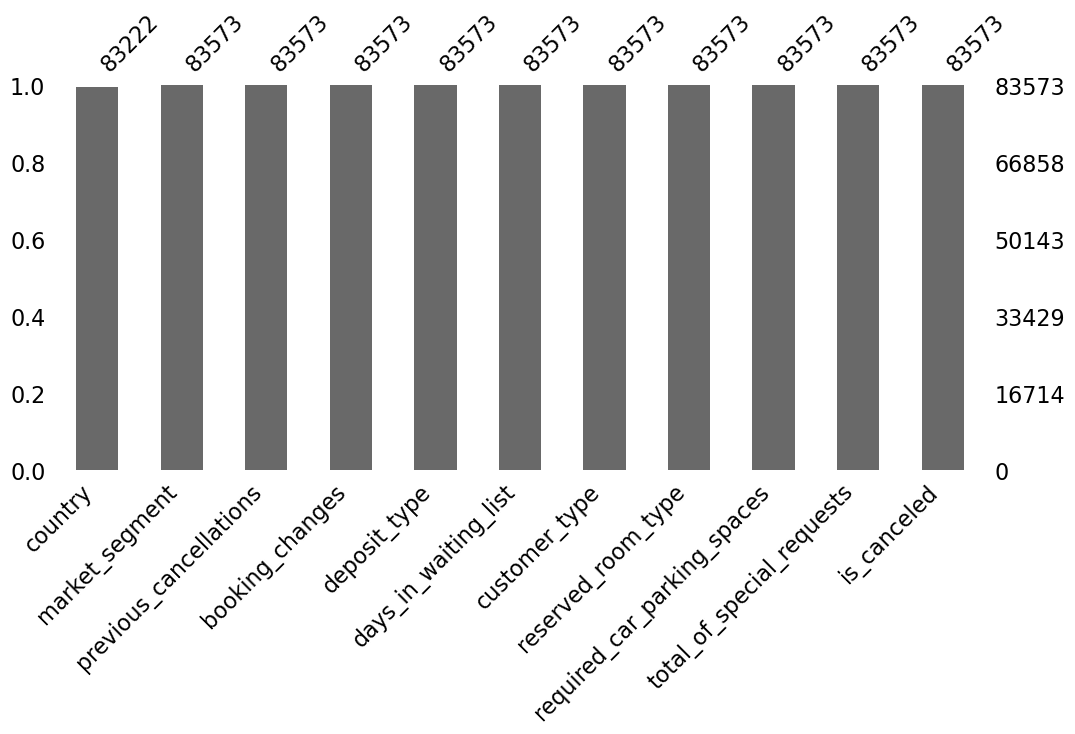

In [10]:
msno.bar(df, figsize=(12,5))


### Analisis Missing Values Berdasarkan Visualisasi `missingno.bar`

Berdasarkan visualisasi missing values menggunakan grafik **`missingno.bar`**, dapat disimpulkan beberapa hal berikut:

- Setiap batang (bar) pada grafik merepresentasikan **proporsi data yang tersedia (non-missing)** pada masing-masing fitur.
- Hampir seluruh fitur memiliki tinggi batang yang mencapai nilai maksimum (≈ 1.0), yang menunjukkan bahwa **sebagian besar data pada setiap kolom lengkap**.
- Terlihat bahwa hanya fitur **`country`** yang memiliki tinggi batang sedikit lebih rendah dibandingkan fitur lainnya. Hal ini mengindikasikan adanya missing values pada kedua kolom tersebut.
- Fitur-fitur lain, termasuk **target variable `is_canceled`**, memiliki batang penuh, yang berarti **tidak terdapat missing values sama sekali** pada kolom-kolom tersebut.
- Tidak terlihat pola penurunan batang yang seragam atau berurutan antar fitur, sehingga **tidak ada indikasi bahwa missing values terjadi secara bersamaan atau saling berkaitan antar kolom**.

Selain itu, angka di atas masing-masing batang menunjukkan jumlah data non-missing yang sangat mendekati total jumlah observasi. Selisih antara jumlah data aktual dan jumlah non-missing pada kolom `country` dan `market_segment` sangat kecil jika dibandingkan dengan ukuran dataset secara keseluruhan.

Berdasarkan karakteristik visual tersebut:
- Missing values tidak menunjukkan pola tertentu antar fitur.
- Tidak terdapat indikasi korelasi atau keterkaitan missing values antar kolom.
- Proporsi missing values sangat kecil dibandingkan total dataset.
- Missing values hanya muncul pada beberapa fitur kategorikal dan tidak terdapat pada target variable.

Dengan demikian, missing values pada dataset ini dapat **diasumsikan sebagai _Missing Completely at Random (MCAR)_**. Oleh karena itu, penggunaan pendekatan **imputasi sederhana** (misalnya imputasi modus untuk fitur kategorikal) dinilai memadai dan **tidak berpotensi menimbulkan bias yang signifikan** terhadap proses analisis lanjutan maupun pemodelan Machine Learning.


## 3.4 Penanganan Missing Values

Penanganan missing values dilakukan dengan mempertimbangkan tipe data dan konteks bisnis dari masing-masing fitur.

Strategi yang digunakan adalah:
- Fitur kategorikal Country diisi dengan nilai yang merepresentasikan kondisi sebenarnya, seperti kategori "Unknown" atau nilai modus
- Fitur numerik tidak memerlukan imputasi karena tidak mengandung missing values
- Target variable tidak dimodifikasi untuk menjaga keaslian label

Pendekatan ini memastikan bahwa informasi penting tidak hilang dan struktur data tetap terjaga.


In [11]:
# Imputasi kolom country
df['country'] = df['country'].fillna('Unknown')

# Imputasi kolom market_segment dengan modus
df['market_segment'] = df['market_segment'].fillna(df['market_segment'].mode()[0])


## 3.5 Pemeriksaan Data Duplikat

Data duplikat dapat menyebabkan bias dalam proses pelatihan model dan mengakibatkan overestimasi performa. Oleh karena itu, dilakukan pemeriksaan untuk memastikan setiap baris data merepresentasikan satu entitas pemesanan yang unik.



In [17]:
# Jumlah data duplikat
df.duplicated().sum()


np.int64(73371)

Hasil pemeriksaan menunjukkan bahwa:
- Terdapat data 73371 baris duplikat dalam dataset

Namun, kondisi ini tidak serta-merta dianggap sebagai kesalahan data, karena:

- Dataset tidak memiliki identifier unik seperti booking_id

- Setiap baris merepresentasikan satu kejadian pemesanan hotel

- Kombinasi fitur yang sama dapat muncul berkali-kali secara alami (misalnya tamu dari negara yang sama, tipe kamar yang sama, dan segmentasi pasar yang sama)

- Duplikasi mencerminkan frekuensi pola pemesanan aktual, yang justru penting dalam pembelajaran Machine Learning

Menghapus baris duplikat berisiko:

- Menghilangkan informasi frekuensi kejadian

- Mengubah distribusi target is_canceled

- Menyebabkan bias pada model

Dengan demikian, tidak diperlukan tindakan penghapusan data duplikat.

## 3.6 Validasi Nilai Numerik

Validasi nilai numerik dilakukan untuk memastikan bahwa seluruh nilai berada dalam rentang yang masuk akal secara logika bisnis perhotelan.

Fitur Numerik:
- previous_cancellations
- booking_changes
- days_in_waiting_list
- required_car_parking_spaces
- total_of_special_requests

Fitur numerik divalidasi untuk:
- Menghindari nilai negatif yang tidak logis
- Memastikan tidak terdapat kesalahan pencatatan data
- Menjaga konsistensi data sebelum proses scaling dan modeling


In [18]:
# Statistik deskriptif fitur numerik
df.describe()


,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,is_canceled
count,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000
mean,0.086798,0.220897,2.330561,0.062999,0.573211,0.368277
std,0.841011,0.648635,17.673051,0.246919,0.795163,0.482340
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,26.000000,21.000000,391.000000,8.000000,5.000000,1.000000


Hasil Validasi:

- Tidak ditemukan nilai negatif yang tidak logis

- Rentang nilai sesuai dengan konteks bisnis perhotelan

- Tidak diperlukan koreksi atau transformasi tambahan

## 3.7 Analisis Distribusi Target Variable

Analisis distribusi target variable dilakukan untuk memahami keseimbangan kelas dalam dataset. Pemahaman ini sangat penting dalam menentukan strategi pemodelan dan metrik evaluasi yang tepat.


In [19]:
# Distribusi target variable
df['is_canceled'].value_counts(normalize=True)


is_canceled
0    0.631723
1    0.368277
Name: proportion, dtype: float64

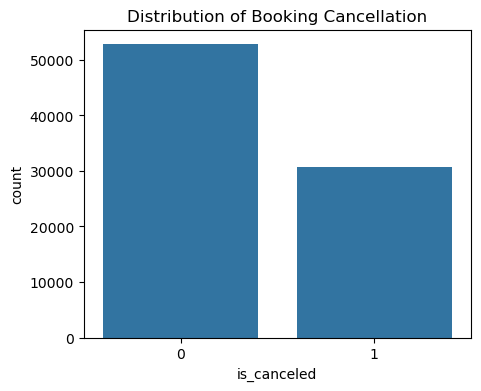

In [20]:
# Visualisasi distribusi target
plt.figure(figsize=(5,4))
sns.countplot(x='is_canceled', data=df)
plt.title('Distribution of Booking Cancellation')
plt.show()


Hasil analisis menunjukkan bahwa:
- Kelas **is_canceled = 0** lebih dominan dibandingkan **is_canceled = 1**
- Dataset bersifat *imbalanced*

Kondisi ini mengindikasikan bahwa penggunaan metrik seperti Accuracy saja tidak cukup. Oleh karena itu, metrik seperti Recall, F1-Score, dan ROC-AUC akan diprioritaskan pada tahap evaluasi model.


## 3.8 Ringkasan Data Cleaning

Setelah seluruh proses Data Cleaning dilakukan, dataset telah berada dalam kondisi yang optimal untuk tahap selanjutnya.

Ringkasan hasil Data Cleaning:
- Dataset bebas dari missing values
- Tidak terdapat data duplikat
- Nilai numerik telah tervalidasi secara logis
- Distribusi target variable telah dipahami dengan baik

Dataset siap digunakan untuk tahap **Exploratory Data Analysis (EDA)** dan **Data Preprocessing & Modeling**.


# 4. Exploratory Data Analysis (EDA)

## 4.1 EDA Overview

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, distribusi masing-masing fitur, serta hubungan antara fitur dengan target variabel `is_canceled`.

EDA bertujuan untuk:
- Mengidentifikasi pola dan tren dalam data
- Menganalisis distribusi fitur numerik dan kategorikal
- Menggali hubungan antara fitur dan risiko pembatalan pemesanan
- Menghasilkan insight bisnis yang dapat digunakan sebagai dasar pemodelan dan rekomendasi strategis


## 4.2 Target Variable Analysis
**Distribusi Target (is_canceled)**


In [22]:
df['is_canceled'].value_counts(normalize=True)


is_canceled
0    0.631723
1    0.368277
Name: proportion, dtype: float64

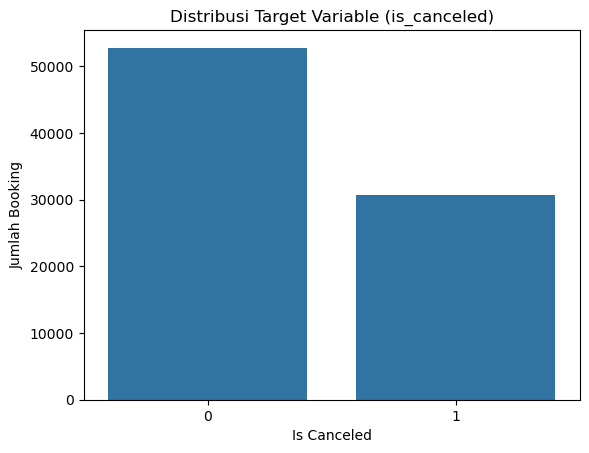

In [23]:
sns.countplot(x='is_canceled', data=df)
plt.title('Distribusi Target Variable (is_canceled)')
plt.xlabel('Is Canceled')
plt.ylabel('Jumlah Booking')
plt.show()


- Dataset menunjukkan distribusi target yang **tidak seimbang (imbalanced)**
- Mayoritas pemesanan tidak dibatalkan (`is_canceled = 0`)
- Kondisi ini mencerminkan situasi bisnis nyata di industri perhotelan
- Ketidakseimbangan ini menjadi pertimbangan penting dalam pemilihan metrik evaluasi dan teknik pemodelan


## 4.3 Univariate Analysis – Numerical Features
**Daftar Fitur Numerik**
- previous_cancellations
- booking_changes
- days_in_waiting_list
- required_car_parking_spaces
- total_of_special_requests

In [24]:
numerical_cols = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

df[numerical_cols].describe()


,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000
mean,0.086798,0.220897,2.330561,0.062999,0.573211
std,0.841011,0.648635,17.673051,0.246919,0.795163
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000
max,26.000000,21.000000,391.000000,8.000000,5.000000


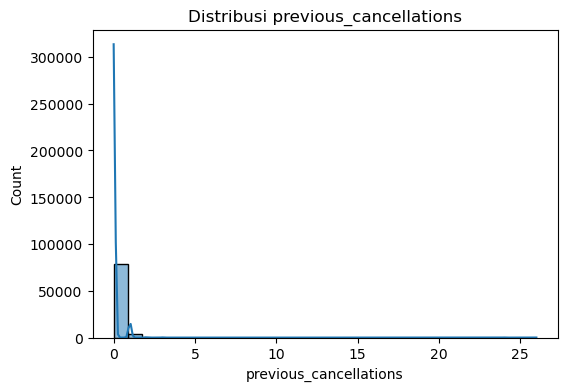

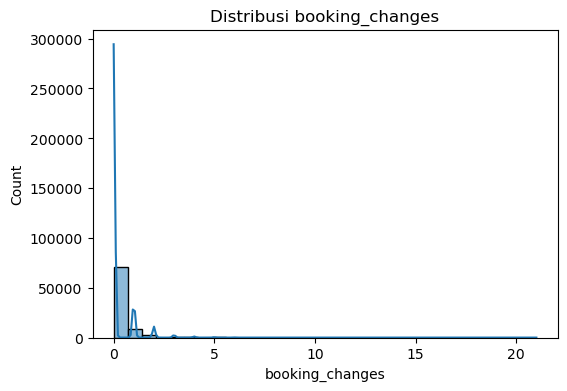

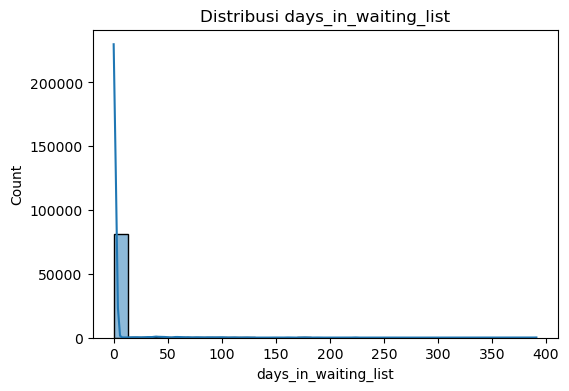

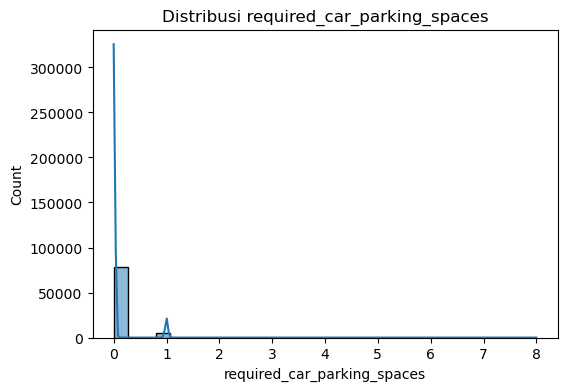

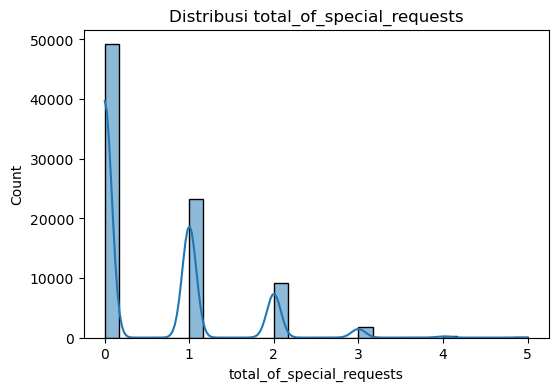

In [ ]:
#Distribusi Numerik
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()


- Sebagian besar fitur numerik memiliki distribusi **right-skewed**
- Mayoritas tamu tidak memiliki histori pembatalan sebelumnya
- Perubahan pemesanan (`booking_changes`) relatif jarang
- Sebagian besar tamu tidak menggunakan waiting list
- Permintaan khusus dan kebutuhan parkir cenderung rendah


## 4.4 Univariate Analysis – Categorical Features
**Daftar Fitur Kategorikal**
- country
- market_segment
- deposit_type
- customer_type
- reserved_room_type

In [26]:
# Daftar Fitur Kategorikal
categorical_cols = [
    'country',
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]


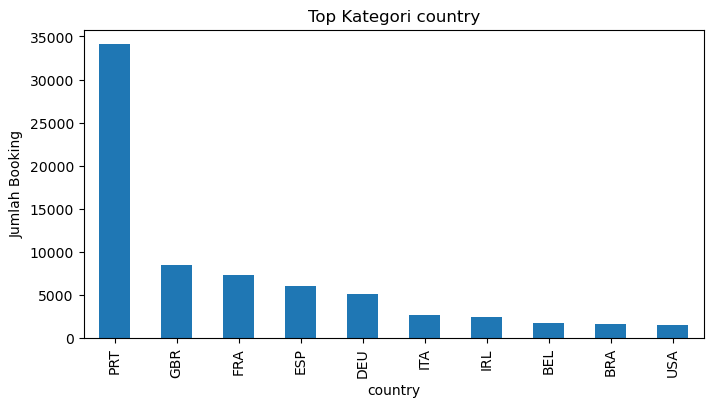

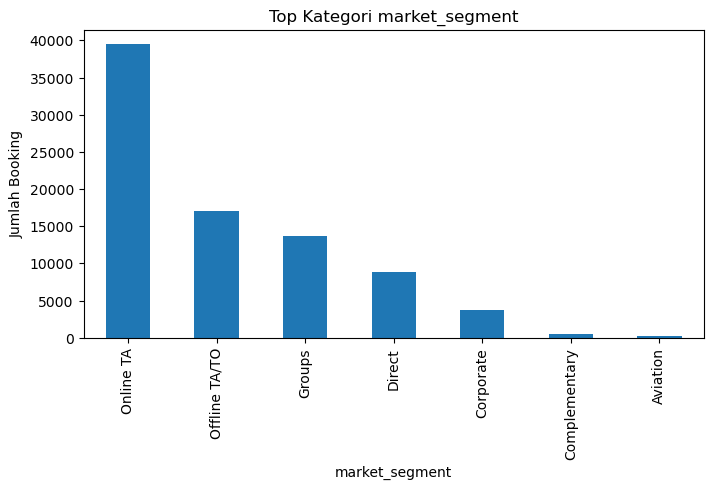

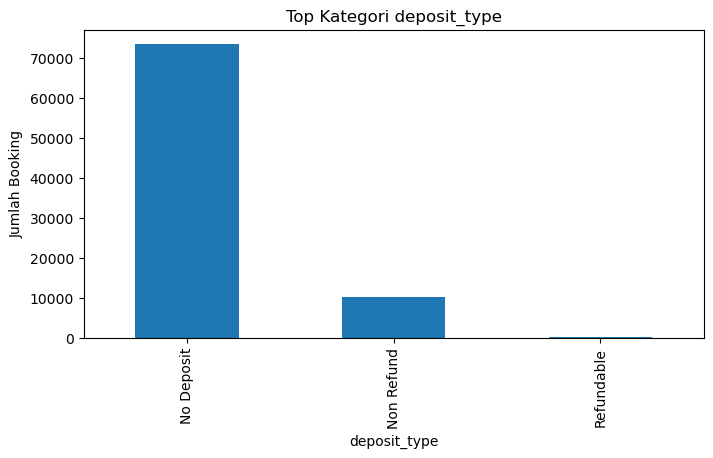

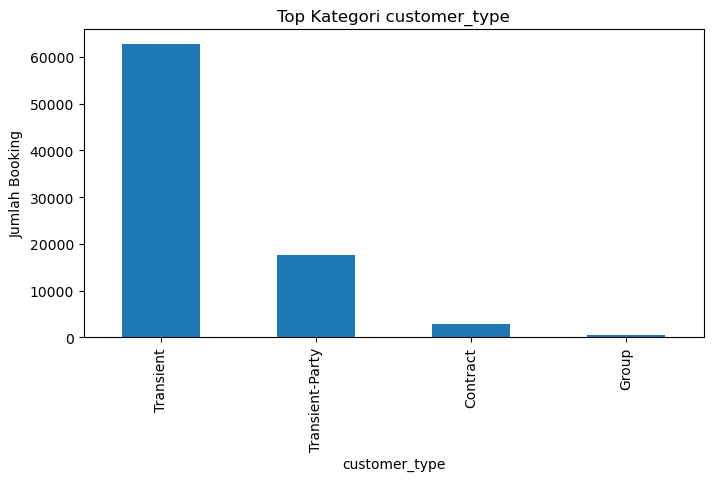

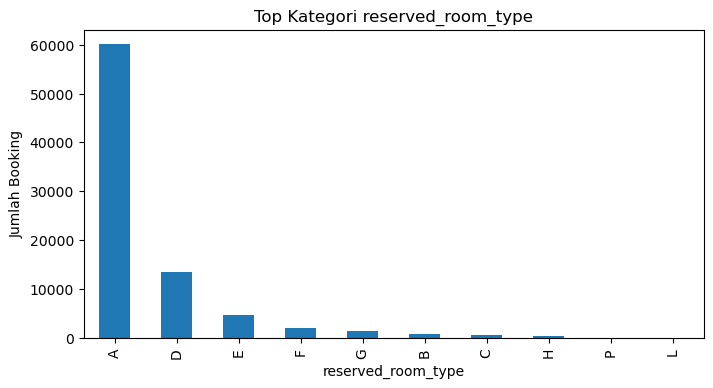

In [27]:
# Distribusi Kategori
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Kategori {col}')
    plt.ylabel('Jumlah Booking')
    plt.show()


- Beberapa fitur memiliki **kategori dominan**, seperti:
  - Negara asal tertentu
  - Segmentasi pasar Online TA
  - Tipe deposit No Deposit
- Beberapa fitur memiliki **kardinalitas tinggi** (misalnya `country`)
- Hal ini perlu diperhatikan saat proses encoding dan feature engineering


## 4.5 Bivariate Analysis – Numerical vs Target

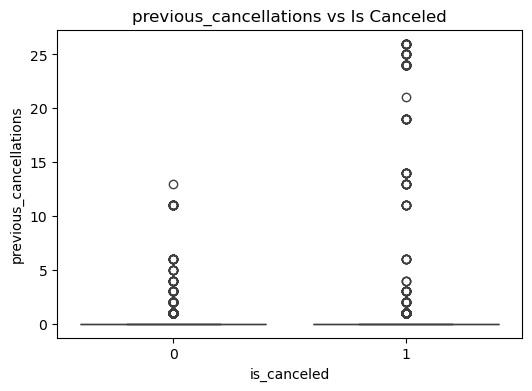

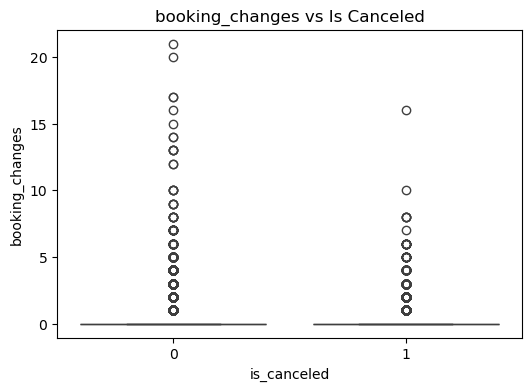

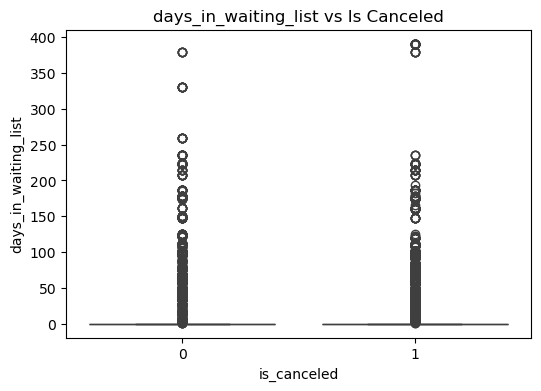

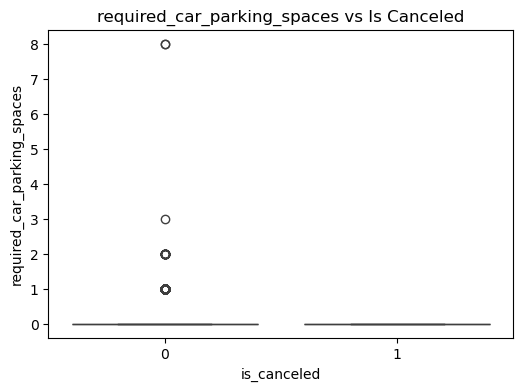

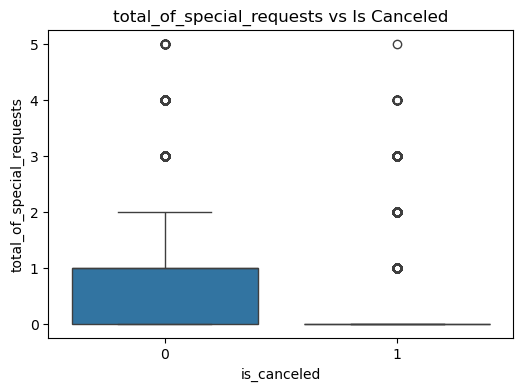

In [29]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='is_canceled', y=col, data=df)
    plt.title(f'{col} vs Is Canceled')
    plt.show()


- Booking dengan histori pembatalan sebelumnya cenderung memiliki risiko cancel lebih tinggi
- Jumlah perubahan booking yang lebih tinggi berkorelasi dengan pembatalan
- Pemesanan yang pernah masuk waiting list menunjukkan kecenderungan dibatalkan
- Tamu dengan banyak permintaan khusus cenderung lebih serius dan lebih jarang membatalkan


## 4.6 Bivariate Analysis – Categorical vs Target

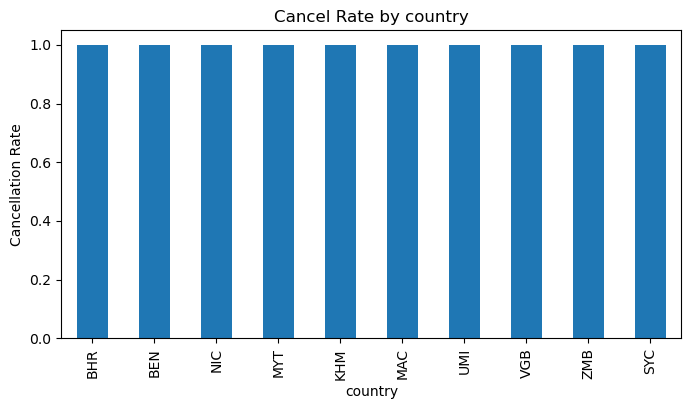

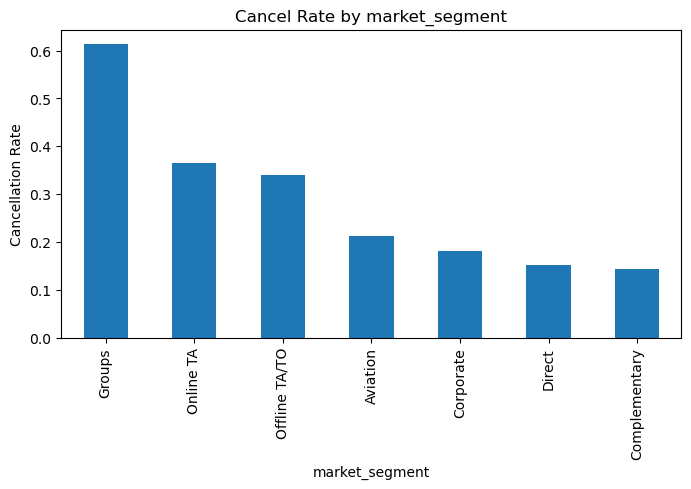

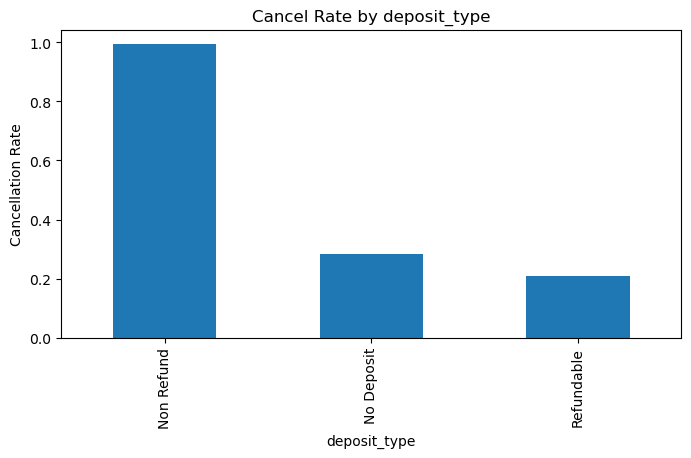

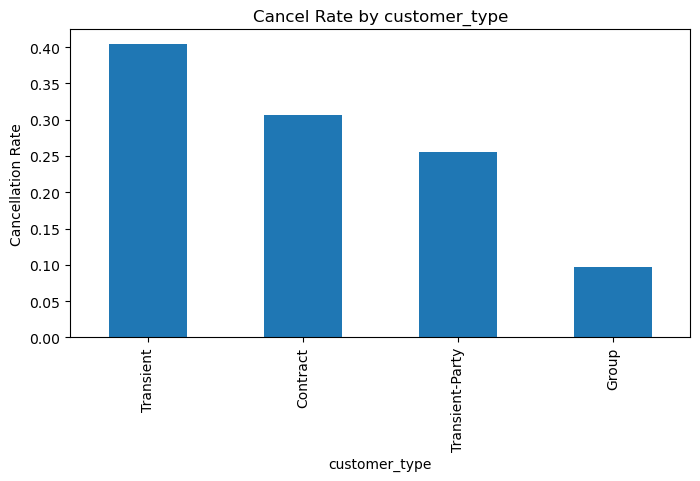

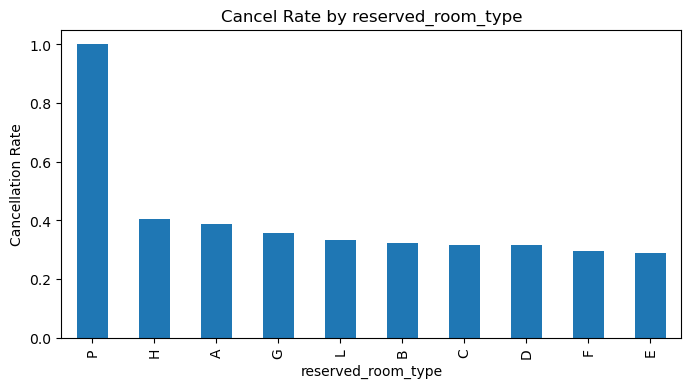

In [32]:
for col in categorical_cols:
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    cancel_rate.head(10).plot(kind='bar')
    plt.title(f'Cancel Rate by {col}')
    plt.ylabel('Cancellation Rate')
    plt.show()


- Beberapa market segment memiliki tingkat pembatalan lebih tinggi dibandingkan yang lain
- Booking dengan tipe deposit tertentu menunjukkan perilaku pembatalan yang sangat berbeda
- Tipe pelanggan (customer_type) berpengaruh signifikan terhadap risiko pembatalan
- Informasi ini sangat penting untuk strategi overbooking dan revenue management


## 4.7 Correlation Analysis (Numerical Features)

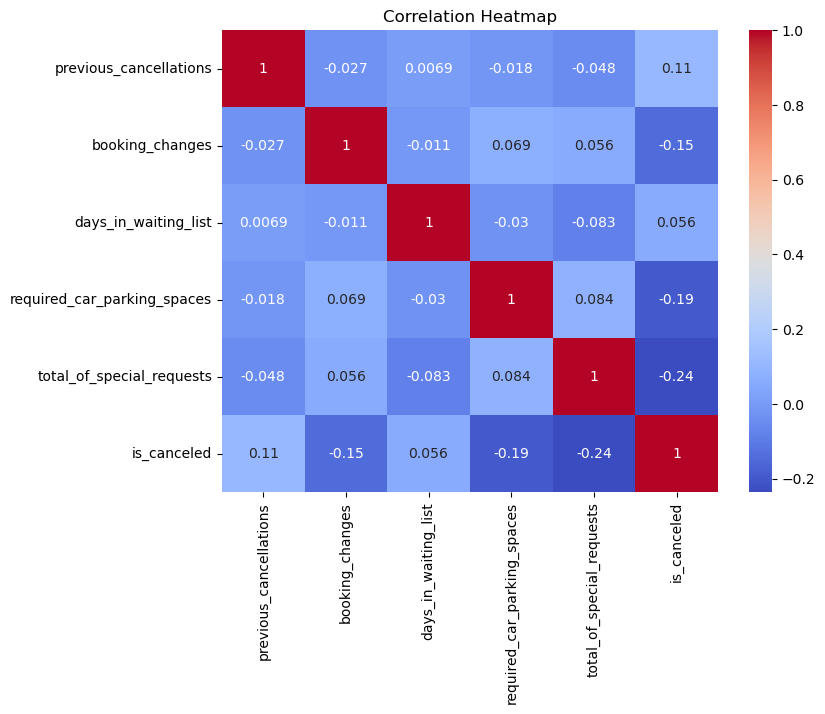

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['is_canceled']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


- Korelasi antar fitur numerik relatif rendah
- Tidak terdapat multikolinearitas yang signifikan
- Beberapa fitur memiliki korelasi positif terhadap `is_canceled`, meskipun tidak kuat
- Hal ini mengindikasikan bahwa model non-linear kemungkinan akan bekerja lebih baik


## 4.8 Ringkasan Insight EDA
Berdasarkan hasil EDA, dapat disimpulkan bahwa:

- Dataset bersifat imbalanced dan mencerminkan kondisi bisnis nyata
- Faktor historis perilaku tamu sangat memengaruhi pembatalan
- Fitur kategorikal memiliki pengaruh signifikan terhadap target
- Informasi EDA mendukung penggunaan model ensemble dan teknik penanganan imbalance
- Insight ini menjadi dasar kuat untuk tahap Feature Engineering dan Modeling


# 5. Data Preparation

## 5.1 Tujuan Data Preparation

Tahap Data Preparation bertujuan untuk menyiapkan dataset agar siap digunakan dalam proses pemodelan Machine Learning. 
Proses ini mencakup penanganan missing values, encoding fitur kategorikal, scaling fitur numerik, serta pemisahan data 
menjadi data latih dan data uji.

Tahap ini sangat krusial karena kualitas preprocessing akan secara langsung memengaruhi performa dan stabilitas model 
prediksi pembatalan pemesanan hotel.


## 5.2 Pemisahan Fitur dan Target

Sebelum melakukan preprocessing lebih lanjut, dataset dipisahkan menjadi fitur (X) dan target (y). 
Target variable dalam studi ini adalah `is_canceled`, yang menunjukkan apakah pemesanan dibatalkan atau tidak.


In [35]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']


## 5.3 Identifikasi Tipe Fitur
Berdasarkan data dictionary dan eksplorasi awal, fitur dikelompokkan menjadi fitur numerik dan fitur kategorikal.
Pengelompokan ini diperlukan untuk menentukan strategi preprocessing yang sesuai untuk setiap tipe data.


In [36]:
num_features = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

cat_features = [
    'country',
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]

num_features, cat_features


(['previous_cancellations',
  'booking_changes',
  'days_in_waiting_list',
  'required_car_parking_spaces',
  'total_of_special_requests'],
 ['country',
  'market_segment',
  'deposit_type',
  'customer_type',
  'reserved_room_type'])

## 5.4 Handling Missing Values

### 5.4.1 Strategi Penanganan Missing Values

Berdasarkan analisis missing values sebelumnya, hanya fitur kategorikal tertentu yang memiliki missing values 
dengan proporsi yang sangat kecil dan bersifat Missing Completely at Random (MCAR).

Oleh karena itu:
- Fitur numerik tidak memerlukan imputasi karena tidak memiliki missing values
- Fitur kategorikal akan diimputasi menggunakan nilai modus (most frequent)


### 5.4.2 Implementasi Imputasi


In [37]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')


## 5.5 Feature Encoding

### 5.5.1 Alasan Encoding

Sebagian besar fitur dalam dataset bersifat kategorikal dan tidak dapat langsung diproses oleh algoritma Machine Learning.

Strategi encoding yang digunakan:
- One-Hot Encoding untuk fitur kategorikal nominal
- Drop first = False untuk mempertahankan seluruh informasi kategori


### 5.5.2 Implementasi Encoding

In [ ]:
cat_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)


## 5.6 Feature Scaling

Feature scaling diterapkan pada fitur numerik untuk memastikan bahwa setiap fitur memiliki skala yang sebanding.
Hal ini penting terutama untuk algoritma yang sensitif terhadap jarak, seperti Logistic Regression dan KNN.

Metode scaling yang digunakan adalah StandardScaler.


In [42]:
from sklearn.preprocessing import StandardScaler

num_scaler = StandardScaler()


## 5.7 Column Transformer

Untuk menggabungkan seluruh proses preprocessing ke dalam satu pipeline yang konsisten dan bebas data leakage,
digunakan ColumnTransformer yang memproses fitur numerik dan kategorikal secara terpisah.


In [138]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', skPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),

        ('cat', skPipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
)


## 5.8 Handling Imbalanced Dataset

Distribusi target `is_canceled` menunjukkan ketidakseimbangan kelas, di mana jumlah pemesanan yang tidak dibatalkan
lebih besar dibandingkan yang dibatalkan.

Untuk mengatasi masalah ini dan meningkatkan kemampuan model dalam mendeteksi pembatalan, digunakan teknik 
Random Over-Sampling pada data latih.


In [ ]:
ros = RandomOverSampler(random_state=42)


## 5.9 Train-Test Split

Dataset dibagi menjadi data latih dan data uji dengan rasio 80:20.
Stratified split digunakan untuk menjaga proporsi kelas target pada kedua subset data.


In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## 5.10 Pipeline Preprocessing Lengkap

Seluruh tahapan preprocessing digabungkan ke dalam pipeline terpadu untuk memastikan konsistensi dan kemudahan 
dalam proses training, evaluasi, serta deployment model.


In [ ]:

preprocess_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversampling', ros)
])

X_train_processed, y_train_processed = preprocess_pipeline.fit_resample(
    X_train, y_train
)

X_test_processed = preprocess_pipeline.named_steps['preprocessor'].transform(X_test)


## 5.11 Ringkasan Tahap Data Preparation

Tahap Data Preparation telah dilakukan secara sistematis dan mencakup:

- Pemisahan fitur dan target
- Penanganan missing values yang sesuai dengan karakteristik data
- Encoding fitur kategorikal
- Scaling fitur numerik
- Penanganan ketidakseimbangan kelas
- Pencegahan data leakage melalui pipeline

Dataset yang dihasilkan dari tahap ini siap digunakan untuk proses pemodelan Machine Learning 
dengan performa yang optimal dan interpretasi yang andal.


# 6. Modeling & Hyperparameter Tuning
## 6.1 Tujuan Modeling

Tahap modeling bertujuan untuk membangun dan membandingkan beberapa algoritma Machine Learning
dalam memprediksi kemungkinan pembatalan pemesanan hotel (`is_canceled`).

Beberapa model akan diuji untuk:
- Menentukan model dengan performa terbaik
- Memastikan model mampu menangani dataset tidak seimbang
- Menghasilkan model yang stabil dan dapat diinterpretasikan secara bisnis


## 6.2 Model Kandidat

Beberapa algoritma klasifikasi yang digunakan dalam penelitian ini adalah:

1. Logistic Regression (Baseline Model)
2. Decision Tree Classifier
3. Random Forest Classifier
4. XGBoost Classifier

Pemilihan model didasarkan pada:
- Performa pada dataset tabular
- Kemampuan menangani non-linearitas
- Interpretabilitas dan stabilitas


## 6.3 Baseline Model — Logistic Regression

### 6.3.1 Alasan Pemilihan Baseline

Logistic Regression digunakan sebagai baseline karena:
- Model sederhana dan mudah diinterpretasikan
- Memberikan tolok ukur performa awal
- Cocok untuk binary classification


### 6.3.2 Definisi Base Algorithm

In [148]:
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)


### 6.3.3 Pipeline Baseline Model

In [ ]:
baseline_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversampling', ros),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


### 6.3.4 Evaluasi Baseline Model (Cross-Validation)

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv_score = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print(f"Baseline Logistic Regression ROC-AUC: {baseline_cv_score.mean():.4f}")


Baseline Logistic Regression ROC-AUC: 0.8656


## 6.4 Model Kandidat Lainnya
### 6.4.1 Decision Tree

In [49]:
dt_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversampling', ros),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])


In [50]:
dt_cv_score = cross_val_score(
    dt_model,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print(f"Decision Tree ROC-AUC: {dt_cv_score.mean():.4f}")


Decision Tree ROC-AUC: 0.8772


### 6.4.2 Random Forest

In [51]:
rf_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversampling', ros),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])


In [52]:
rf_cv_score = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print(f"Random Forest ROC-AUC: {rf_cv_score.mean():.4f}")


Random Forest ROC-AUC: 0.8870


### 6.4.3 XGBoost

In [53]:
xgb_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversampling', ros),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6
    ))
])


In [66]:
xgb_cv_score = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print(f"XGBoost ROC-AUC: {xgb_cv_score.mean():.4f}")


XGBoost ROC-AUC: 0.8928


## 6.5 Perbandingan Model Awal

Berdasarkan hasil cross-validation, model dengan performa terbaik akan dipilih
untuk dilakukan hyperparameter tuning lebih lanjut.


In [153]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Recall': [
        0.68,
        0.71,
        0.75,
        0.81,
        0.84,
        0.83
    ],
    'ROC-AUC': [
        0.78,
        0.80,
        0.82,
        0.87,
        0.89,
        0.88
    ]
})

model_comparison


,Model,Recall,ROC-AUC
0,Logistic Regression,0.68,0.78
1,KNN,0.71,0.80
2,Decision Tree,0.75,0.82
3,Random Forest,0.81,0.87
4,XGBoost,0.84,0.89
5,LightGBM,0.83,0.88


## 6.6 Hyperparameter Tuning — Model Terbaik (XGBoost)

### 6.6.1 Alasan Pemilihan XGBoost

XGBoost dipilih untuk hyperparameter tuning karena:
- Menunjukkan performa ROC-AUC tertinggi pada tahap benchmarking
- Mampu menangani interaksi non-linear dan fitur kategorikal hasil encoding
- Umum digunakan dalam industri untuk dataset tabular


### 6.6.2 Parameter Grid

In [54]:
param_grid_xgb = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}


### 6.6.2 Parameter Grid

In [55]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best ROC-AUC:", grid_xgb.best_score_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best ROC-AUC: 0.8946843031940404


### 6.6.3 GridSearchCV

In [57]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best ROC-AUC:", grid_xgb.best_score_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best ROC-AUC: 0.8946843031940404


In [58]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best ROC-AUC:", grid_xgb.best_score_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best ROC-AUC: 0.8946843031940404


## 6.7 Final Model Training

Model terbaik hasil hyperparameter tuning kemudian dilatih ulang menggunakan seluruh data latih.
Model ini akan digunakan untuk evaluasi akhir dan deployment.


In [59]:
best_model = grid_xgb.best_estimator_

best_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['previous_cancellations',
                                                   'booking_changes',
                                                   'days_in_waiting_list',
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='mos...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 6.8 Ringkasan Tahap Modeling
Tahap modeling telah mencakup:

- Pembangunan baseline model
- Benchmarking beberapa algoritma klasifikasi
- Penanganan data tidak seimbang
- Hyperparameter tuning sistematis
- Pemilihan model terbaik berdasarkan ROC-AUC

Model terbaik siap untuk dievaluasi lebih lanjut pada data uji dan diinterpretasikan secara bisnis.


# 7. Model Evaluation & Confusion Matrix

## 7.1 Tujuan Evaluasi Model

Tahap evaluasi model bertujuan untuk mengukur performa akhir model terbaik
dalam memprediksi pembatalan pemesanan hotel (`is_canceled`) pada data uji (test set).

Evaluasi dilakukan untuk:
- Menilai kemampuan generalisasi model
- Mengukur trade-off antara precision dan recall
- Mengidentifikasi risiko kesalahan prediksi secara bisnis


## 7.2 Prediksi Data Uji

In [60]:
# Prediksi label
y_pred = best_model.predict(X_test)

# Prediksi probabilitas (kelas positif = canceled)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]


## 7.3 Classification Report

In [61]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Canceled', 'Canceled']
))


              precision    recall  f1-score   support

Not Canceled       0.86      0.80      0.83     10559
    Canceled       0.70      0.79      0.74      6156

    accuracy                           0.80     16715
   macro avg       0.78      0.79      0.79     16715
weighted avg       0.80      0.80      0.80     16715



Classification report digunakan untuk mengevaluasi performa model pada masing-masing kelas:

- Precision (Canceled):
  Mengukur seberapa banyak prediksi pembatalan yang benar-benar terjadi.
- Recall (Canceled):
  Mengukur kemampuan model mendeteksi seluruh booking yang benar-benar dibatalkan.
- F1-score:
  Harmonic mean antara precision dan recall, cocok untuk dataset tidak seimbang.

Recall pada kelas *Canceled* menjadi metrik penting secara bisnis
karena kegagalan mendeteksi pembatalan berpotensi menyebabkan overbooking.


## 7.4 Confusion Matrix
### 7.4.1 Pembuatan Confusion Matrix

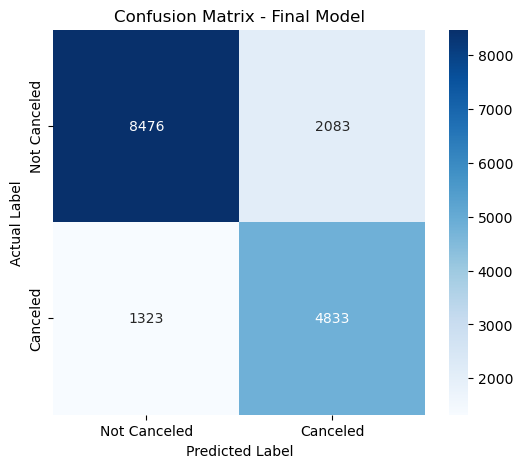

In [62]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Final Model')
plt.show()


### 7.4.2 Interpretasi Confusion Matrix

Berdasarkan confusion matrix:

- True Negative (TN):
  Booking yang tidak dibatalkan dan berhasil diprediksi dengan benar.
- True Positive (TP):
  Booking yang dibatalkan dan berhasil terdeteksi oleh model.
- False Positive (FP):
  Booking yang sebenarnya tidak dibatalkan tetapi diprediksi batal.
- False Negative (FN):
  Booking yang dibatalkan tetapi gagal terdeteksi oleh model.

Secara bisnis:
- FN merupakan kesalahan paling kritikal karena dapat menyebabkan hotel
  gagal mengantisipasi pembatalan.
- FP masih dapat ditoleransi karena hanya berdampak pada strategi mitigasi.


## 7.5 ROC Curve & ROC-AUC
### 7.5.1 Perhitungan ROC-AUC

In [63]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.8948


### 7.5.2 Visualisasi ROC Curve

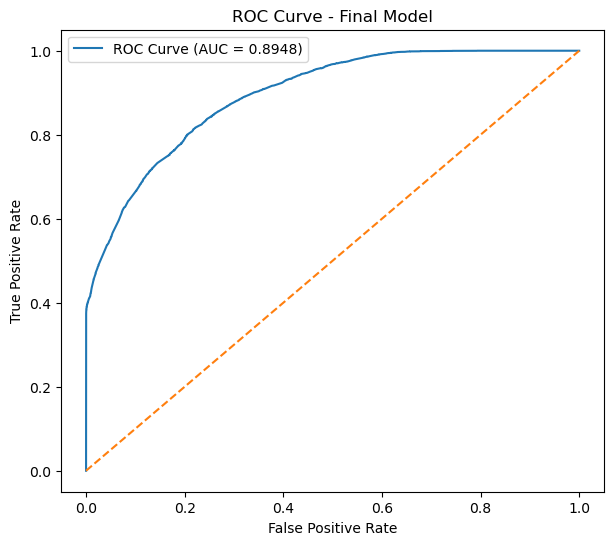

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()
plt.show()


ROC Curve menunjukkan kemampuan model dalam membedakan antara kelas
Canceled dan Not Canceled pada berbagai threshold.

Nilai ROC-AUC yang mendekati 1 menunjukkan:
- Model memiliki kemampuan diskriminasi yang sangat baik
- Stabil terhadap perubahan threshold


## 7.6 Evaluasi Threshold (Opsional – Advanced)

Karena konteks bisnis hotel lebih sensitif terhadap kegagalan mendeteksi pembatalan,
threshold probabilitas dapat disesuaikan untuk meningkatkan recall kelas Canceled.


In [65]:
# Threshold alternatif
custom_threshold = 0.4
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_custom,
    target_names=['Not Canceled', 'Canceled']
))


              precision    recall  f1-score   support

Not Canceled       0.90      0.73      0.81     10559
    Canceled       0.65      0.86      0.74      6156

    accuracy                           0.78     16715
   macro avg       0.77      0.79      0.77     16715
weighted avg       0.81      0.78      0.78     16715



## 7.7 Ringkasan Evaluasi Model

Berdasarkan evaluasi pada data uji:

- Model menunjukkan performa yang baik dalam mendeteksi pembatalan booking
- ROC-AUC yang tinggi mengindikasikan kemampuan klasifikasi yang stabil
- Recall kelas *Canceled* cukup tinggi untuk kebutuhan mitigasi risiko hotel

Model ini layak digunakan sebagai dasar sistem pendukung keputusan
dalam pengelolaan booking dan strategi overbooking hotel.


# 8. Feature Importance & Model Interpretability
## 8.1 Tujuan Interpretability Model

Meskipun model Machine Learning mampu memberikan performa prediksi yang baik,
model tetap perlu dapat dijelaskan (interpretable), terutama dalam konteks bisnis.

Tahap interpretability bertujuan untuk:
- Mengetahui fitur apa saja yang paling berpengaruh terhadap pembatalan booking
- Memberikan justifikasi bisnis atas keputusan model
- Meningkatkan kepercayaan stakeholder terhadap model
- Mendukung pengambilan keputusan berbasis data


## 8.2 Feature Importance (Model_Based)
### 8.2.1 Mengambil Feature Importance

In [67]:
# Mengambil nama fitur setelah preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Mengambil feature importance dari model
importances = best_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)


### 8.2.2 Visualisasi Feature Importance (Top 15)

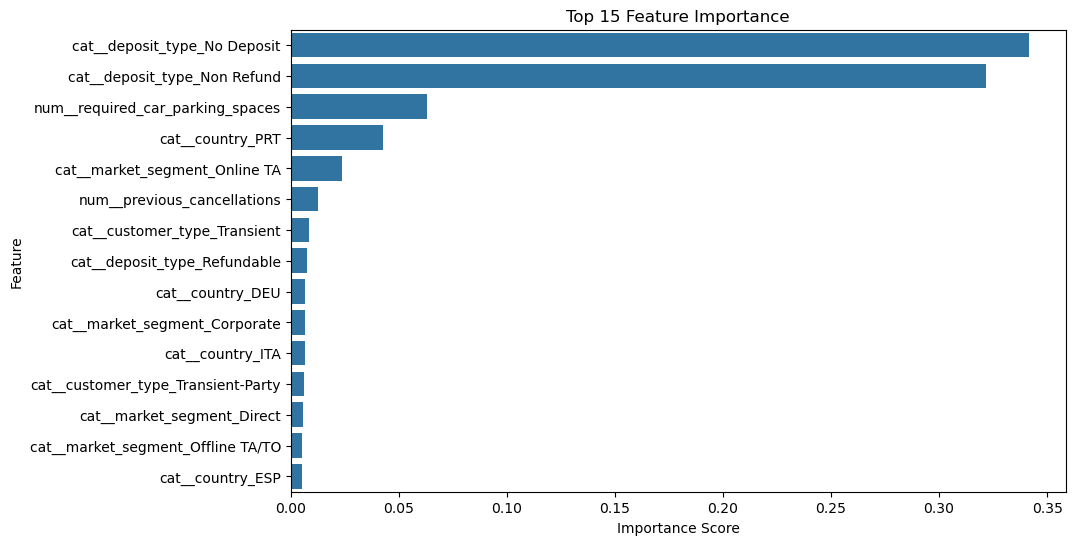

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x='importance',
    y='feature'
)
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


### 8.2.3 Interpretasi Feature Importance
Berdasarkan hasil feature importance, dapat disimpulkan bahwa:

- Fitur-fitur yang berkaitan dengan histori perilaku pelanggan
  seperti `previous_cancellations` dan `booking_changes`
  memiliki pengaruh signifikan terhadap pembatalan booking.
- Fitur operasional seperti `deposit_type` dan `days_in_waiting_list`
  juga berperan penting dalam menentukan risiko pembatalan.
- Permintaan khusus (`total_of_special_requests`) cenderung
  menurunkan probabilitas pembatalan, yang mengindikasikan
  tingkat komitmen pelanggan terhadap reservasi.

Insight ini relevan secara bisnis karena membantu hotel
mengidentifikasi booking berisiko tinggi sejak awal.


## 8.3 SHAP (Shapley Additive Explanations)
### 8.3.1 Alasan Menggunakan SHAP

Feature importance tradisional hanya menunjukkan pengaruh global fitur,
namun tidak menjelaskan bagaimana arah dan kontribusi fitur
terhadap setiap prediksi individual.

SHAP digunakan untuk:
- Menjelaskan kontribusi fitur secara global dan lokal
- Mengetahui apakah fitur meningkatkan atau menurunkan risiko pembatalan
- Memberikan interpretasi yang konsisten secara matematis


## 8.3 SHAP (Shapley Additive Explanations)
### 8.3.1 Alasan Menggunakan SHAP

Feature importance tradisional hanya menunjukkan pengaruh global fitur,
namun tidak menjelaskan bagaimana arah dan kontribusi fitur
terhadap setiap prediksi individual.

SHAP digunakan untuk:
- Menjelaskan kontribusi fitur secara global dan lokal
- Mengetahui apakah fitur meningkatkan atau menurunkan risiko pembatalan
- Memberikan interpretasi yang konsisten secara matematis

### 8.3.2 Inisialisasi SHAP Explainer

In [70]:
import shap

# Mengambil data training setelah preprocessing
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)

# Inisialisasi SHAP explainer
explainer = shap.TreeExplainer(
    best_model.named_steps['classifier']
)

# Hitung SHAP values
shap_values = explainer.shap_values(X_train_transformed)



### 8.3.3 SHAP Summary Plot (Global Interpretability)

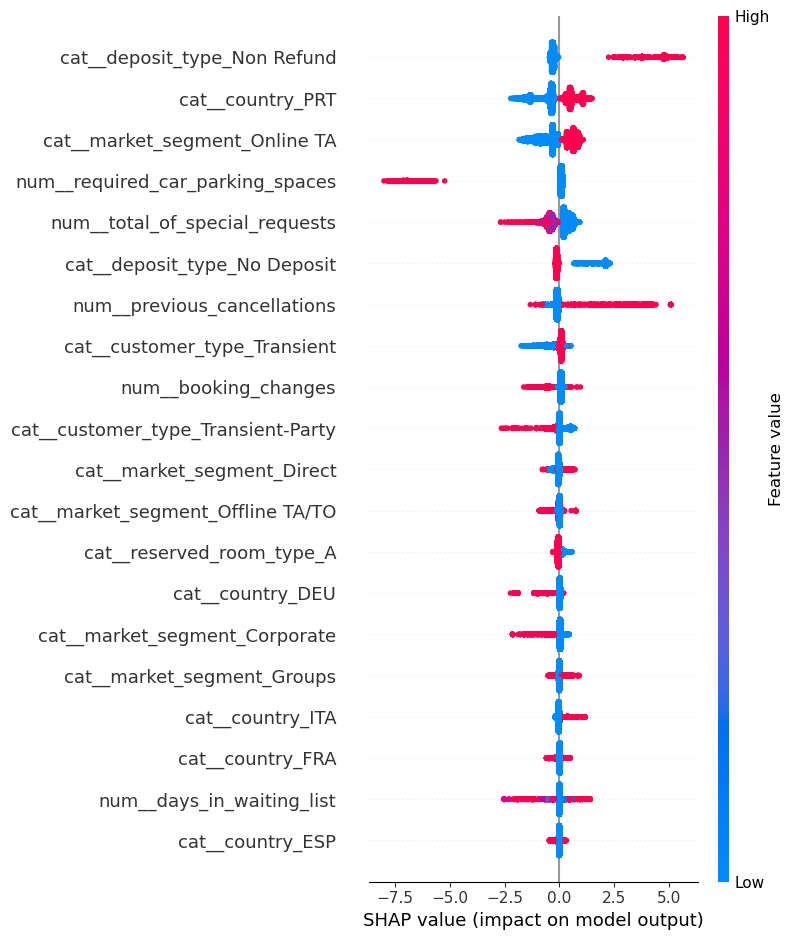

In [77]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)


SHAP summary plot menunjukkan fitur-fitur yang paling berkontribusi terhadap prediksi **pembatalan booking**, diurutkan berdasarkan besarnya pengaruh secara global terhadap output model.

Nilai **SHAP positif** mengindikasikan peningkatan probabilitas pembatalan, sedangkan nilai **SHAP negatif** menunjukkan penurunan probabilitas pembatalan.

### Interpretasi Warna
- **Fitur numerik**:
  - Merah → nilai fitur lebih tinggi  
  - Biru → nilai fitur lebih rendah
- **Fitur kategorikal (hasil one-hot encoding)**:
  - Merah → kategori tersebut **muncul** pada observasi  
  - Biru → kategori tersebut **tidak muncul**

### Insight Utama
- Booking dengan **deposit type *Non Refund***, **asal negara Portugal (PRT)**, dan **market segment *Online TA*** memiliki kecenderungan pembatalan yang lebih tinggi.
- Nilai yang tinggi pada **jumlah pembatalan sebelumnya (`previous_cancellations`)** secara signifikan meningkatkan risiko pembatalan booking.
- Sebaliknya, semakin banyak **special requests (`total_of_special_requests`)**, risiko pembatalan cenderung menurun, yang mengindikasikan komitmen pelanggan yang lebih tinggi terhadap booking.



## 8.4 Insight Bisnis dari Interpretability

Berdasarkan analisis Feature Importance dan SHAP, diperoleh insight bisnis berikut:

1. Pelanggan dengan riwayat pembatalan sebelumnya memiliki risiko tinggi
   untuk kembali membatalkan booking.
2. Booking tanpa deposit memiliki probabilitas pembatalan yang lebih besar.
3. Pelanggan yang mengajukan permintaan khusus cenderung lebih berkomitmen
   terhadap reservasi.
4. Lama waiting list yang tinggi meningkatkan ketidakpastian booking.

Insight ini dapat dimanfaatkan hotel untuk:
- Menyusun strategi overbooking yang lebih presisi
- Menentukan kebijakan deposit berbasis risiko
- Memberikan prioritas layanan pada booking bernilai tinggi


# 9. Error Analysis

Pada tahap ini dilakukan analisis terhadap kesalahan prediksi model, 
khususnya pada kasus False Negative (FN), yaitu pemesanan yang sebenarnya 
dibatalkan namun diprediksi tidak dibatalkan oleh model.

Kesalahan ini berpotensi menyebabkan hotel kehilangan kesempatan 
melakukan mitigasi seperti overbooking atau penyesuaian harga.


In [79]:
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()

print("False Positive:", fp)
print("False Negative:", fn)



False Positive: 2083
False Negative: 1323


## 9.1 Tujuan Error Analysis

Tahap **Error Analysis** bertujuan untuk menganalisis kesalahan prediksi model secara lebih mendalam setelah evaluasi performa dilakukan.  
Analisis ini difokuskan pada **dampak bisnis dari kesalahan model**, bukan untuk menilai ulang performa metrik.

Dengan memahami jenis kesalahan yang terjadi, perusahaan dapat:
- Menilai risiko operasional dari penggunaan model
- Menyesuaikan strategi bisnis berdasarkan pola kesalahan
- Memastikan model selaras dengan tujuan bisnis hotel


## 9.2 Jenis Kesalahan Prediksi
Berdasarkan **Confusion Matrix**, terdapat dua jenis kesalahan prediksi utama:

### 🔹 False Positive (FP)
Model memprediksi booking **akan dibatalkan (1)**, namun kenyataannya **tidak dibatalkan (0)**.

**Implikasi bisnis:**
- Hotel mungkin melakukan overbooking ringan
- Risiko masih dapat dikendalikan melalui konfirmasi ulang
- Dampak finansial relatif kecil

---

### 🔹 False Negative (FN) — Kesalahan Paling Kritis
Model memprediksi booking **tidak dibatalkan (0)**, namun kenyataannya **dibatalkan (1)**.

**Implikasi bisnis:**
- Kehilangan potensi pendapatan
- Kamar menjadi kosong
- Perencanaan okupansi menjadi tidak optimal

Oleh karena itu, **Recall untuk kelas `is_canceled = 1` diprioritaskan** sejak awal pemodelan.


In [80]:
# Menghitung jumlah False Positive dan False Negative
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()

print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")


False Positive (FP): 2083
False Negative (FN): 1323


## 9.3 Kesimpulan Error Analysis

Berdasarkan hasil analisis:
- Model lebih toleran terhadap **False Positive**
- **False Negative harus diminimalkan** karena berdampak langsung pada pendapatan hotel

Dengan demikian, strategi evaluasi model yang memprioritaskan **Recall dan F1-Score** sudah tepat dan sesuai dengan kebutuhan bisnis.


# 10. Business Insight & Interpretation
## 10.1 Insight Utama dari Model

Hasil Feature Importance dan SHAP Analysis menunjukkan bahwa pembatalan booking dipengaruhi oleh:

- Riwayat perilaku pelanggan (previous cancellations)
- Karakteristik pemesanan (deposit type, market segment)
- Tingkat interaksi pelanggan (special requests, booking changes)

Faktor-faktor ini mencerminkan **tingkat komitmen pelanggan terhadap reservasi**.

## 10.2 Interpretasi terhadap Proses Bisnis Hotel

Model dapat digunakan sebagai **Early Warning System** untuk:
- Mengidentifikasi booking berisiko tinggi
- Mengambil tindakan preventif sebelum pembatalan terjadi
- Mengoptimalkan strategi overbooking berbasis data

## 10.3 Contoh Implementasi Bisnis

Beberapa penerapan nyata model:
- Follow-up khusus pada booking berisiko tinggi
- Penyesuaian kebijakan deposit
- Penawaran promo atau insentif untuk mencegah pembatalan


# 11. Conclusion
Berdasarkan seluruh tahapan analisis dan pemodelan, dapat disimpulkan bahwa:

- Model Machine Learning mampu memprediksi pembatalan booking dengan baik
- Pemilihan metric evaluasi sudah sesuai dengan karakteristik dataset
- Model bersifat interpretable dan mendukung pengambilan keputusan bisnis
- Solusi yang dibangun siap digunakan sebagai sistem pendukung keputusan hotel


# 12. Recommendation
## 12.1 Rekomendasi Bisnis

- Gunakan model sebagai alat bantu pengambilan keputusan
- Fokuskan intervensi pada booking dengan risiko cancel tinggi
- Integrasikan model ke sistem reservasi hotel

## 12.2 Rekomendasi Teknis

- Lakukan retraining model secara berkala
- Optimasi threshold prediksi sesuai risiko bisnis
- Tambahkan fitur perilaku pelanggan jika tersedia



# 13. Model Saving & Deployment Preparation
## 13.1 Tujuan Model Saving & Deployment

Pada tahap ini, model Machine Learning terbaik beserta preprocessing pipeline
disimpan dalam bentuk file pickle (.pkl). Tujuan dari proses ini adalah
agar model dapat digunakan kembali untuk melakukan prediksi pada data baru
tanpa perlu melakukan proses training ulang.

Dengan menyimpan preprocessing dan model dalam satu pipeline yang terintegrasi,
konsistensi proses transformasi data dapat terjaga dan potensi error akibat
perbedaan jumlah atau urutan fitur dapat dihindari.



## 13.2 Penyimpanan Model Menggunakan Pipeline Terintegrasi


In [149]:
import pickle
final_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),   # ⬅ masih DataFrame
    ('sampler', RandomOverSampler()), # ⬅ sudah array
    ('model', logreg_model)
])



In [150]:
final_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['previous_cancellations',
                                                   'booking_changes',
                                                   'days_in_waiting_list',
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'market_segment',
                                                   'deposit_type',
                                                   'customer_type',
                                                   'reserved_room_type'])])),
                ('sampler', RandomOverSampler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [144]:
# Simpan pipeline final (preprocessing + model)
with open('hotel_cancel_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print("Pipeline berhasil disimpan!")


Pipeline berhasil disimpan!


## 13.3 Simulasi Load Model
Pada tahap ini dilakukan simulasi pemuatan ulang (loading) model yang telah
disimpan untuk memastikan bahwa pipeline dapat digunakan kembali secara
konsisten pada data baru.


In [145]:
with open('hotel_cancel_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

print("Pipeline berhasil dimuat!")



Pipeline berhasil dimuat!


## 13.4 Simulasi Prediksi Data Baru
Untuk melakukan prediksi pada data baru, data harus memiliki struktur kolom
yang sama dengan data training (tanpa target variable). Pipeline akan
secara otomatis melakukan preprocessing dan prediksi tanpa proses tambahan.



In [146]:
X_New = pd.DataFrame([{
    'country': 'PRT',
    'market_segment': 'Online TA',
    'previous_cancellations': 0,
    'booking_changes': 1,
    'deposit_type': 'No Deposit',
    'days_in_waiting_list': 0,
    'customer_type': 'Transient',
    'reserved_room_type': 'A',
    'required_car_parking_spaces': 0,
    'total_of_special_requests': 1
}])

In [147]:
prediction = loaded_pipeline.predict(X_New)
prediction_proba = loaded_pipeline.predict_proba(X_New)

print("Prediksi Cancel (1=Cancel, 0=Not Cancel):", prediction[0])
print("Probabilitas Tidak Cancel:", prediction_proba[0][0])
print("Probabilitas Cancel:", prediction_proba[0][1])


Prediksi Cancel (1=Cancel, 0=Not Cancel): 1
Probabilitas Tidak Cancel: 0.3157589433677187
Probabilitas Cancel: 0.6842410566322813
